# HealthBot: AI-Powered Patient Education System

**Project:** MediTech Solutions HealthBot Prototype  
**Technology Stack:** LangGraph + OpenAI + Tavily Search  
**Purpose:** Provide personalized, on-demand health information to patients

This notebook implements a conversational AI system that:
1. Searches for up-to-date medical information
2. Summarizes content in patient-friendly language
3. Assesses patient comprehension through quizzes
4. Provides educational feedback with citations

---

## 2. Install Required Libraries

Installing all necessary dependencies with specific versions for compatibility (in the virtual environment):

## 1. Create Virtual Environment

Setting up an isolated Python environment for the HealthBot project to avoid conflicts with your main Python installation:

In [1]:
# Create and activate virtual environment for HealthBot project
import subprocess
import sys
import os

# Create virtual environment
venv_name = "healthbot_venv"
print(f"🔧 Creating virtual environment '{venv_name}'...")

try:
    # Create virtual environment
    subprocess.run([sys.executable, "-m", "venv", venv_name], check=True)
    print(f"✅ Virtual environment '{venv_name}' created successfully!")
    
    # Determine the activation script path based on OS
    if os.name == 'nt':  # Windows
        activate_script = os.path.join(venv_name, "Scripts", "activate.ps1")
        python_exe = os.path.join(venv_name, "Scripts", "python.exe")
    else:  # Unix/Linux/MacOS
        activate_script = os.path.join(venv_name, "bin", "activate")
        python_exe = os.path.join(venv_name, "bin", "python")
    
    print(f"📍 Virtual environment created at: {os.path.abspath(venv_name)}")
    print(f"🐍 Python executable: {os.path.abspath(python_exe)}")
    print("\n" + "="*60)
    print("🔧 IMPORTANT: To activate this virtual environment manually:")
    print(f"   Windows PowerShell: .\\{activate_script}")
    print(f"   Windows CMD: {venv_name}\\Scripts\\activate.bat")
    print(f"   Unix/Linux/Mac: source {activate_script}")
    print("="*60)
    
    # Update sys.executable to use the virtual environment
    if os.path.exists(python_exe):
        sys.executable = os.path.abspath(python_exe)
        print(f"✅ Notebook will now use virtual environment Python: {sys.executable}")
    
except subprocess.CalledProcessError as e:
    print(f"❌ Error creating virtual environment: {e}")
    print("Please ensure you have python and venv module installed.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")

🔧 Creating virtual environment 'healthbot_venv'...
✅ Virtual environment 'healthbot_venv' created successfully!
📍 Virtual environment created at: d:\healthCareAgent\healthbot_venv
🐍 Python executable: d:\healthCareAgent\healthbot_venv\Scripts\python.exe

🔧 IMPORTANT: To activate this virtual environment manually:
   Windows PowerShell: .\healthbot_venv\Scripts\activate.ps1
   Windows CMD: healthbot_venv\Scripts\activate.bat
   Unix/Linux/Mac: source healthbot_venv\Scripts\activate.ps1
✅ Notebook will now use virtual environment Python: d:\healthCareAgent\healthbot_venv\Scripts\python.exe


In [1]:
# Install required libraries for HealthBot prototype from requirements.txt
import subprocess
import sys
import os

# Verify installation by importing key modules
print("\n🧪 Testing imports...")
try:
    import langchain
    print("✅ langchain imported successfully")
    
    import langchain_openai
    print("✅ langchain_openai imported successfully")
    
    import langgraph
    print("✅ langgraph imported successfully")
    
    import tavily
    print("✅ tavily imported successfully")
    
    import dotenv
    print("✅ python-dotenv imported successfully")
    
    print("\n🎉 All key modules imported successfully!")
    print("✅ Environment is ready for HealthBot development!")
    
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Some packages may not have installed correctly.")
    print("Please check the installation output above.")
except Exception as e:
    print(f"❌ Unexpected error during import testing: {e}")


🧪 Testing imports...
✅ langchain imported successfully
✅ langchain_openai imported successfully
✅ langgraph imported successfully
✅ tavily imported successfully
✅ python-dotenv imported successfully

🎉 All key modules imported successfully!
✅ Environment is ready for HealthBot development!


## 3. Load Environment Variables and API Keys

**Setup Instructions:**
1. **Tavily Account:** Sign up at [https://app.tavily.com/home](https://app.tavily.com/home) for free web search API (1000 requests free)
2. **OpenAI Account:** Get your API key from [https://platform.openai.com/api-keys](https://platform.openai.com/api-keys)
3. **Create config.env file** in the same directory as this notebook with:

```
OPENAI_API_KEY="sk-**********"
TAVILY_API_KEY="tvly-********"
```

In [2]:
# Load environment variables from config.env file
from dotenv import load_dotenv
import os

# Load the config.env file
load_dotenv('config.env')

# Verify that both API keys are loaded
try:
    assert os.getenv('OPENAI_API_KEY') is not None, "OPENAI_API_KEY not found in config.env"
    assert os.getenv('TAVILY_API_KEY') is not None, "TAVILY_API_KEY not found in config.env"
    
    print("✅ Environment variables loaded successfully!")
    print(f"✅ OpenAI API Key: {'*' * 20}...{os.getenv('OPENAI_API_KEY')[-4:]}")
    print(f"✅ Tavily API Key: {'*' * 20}...{os.getenv('TAVILY_API_KEY')[-4:]}")
    
except AssertionError as e:
    print(f"❌ Error: {e}")
    print("Please create a 'config.env' file with your API keys.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")

✅ Environment variables loaded successfully!
✅ OpenAI API Key: ********************...5008
✅ Tavily API Key: ********************...6Okb


## 4. Initialize LangChain Components

Setting up the core LangChain and LangGraph components for our workflow:

In [3]:
# Import core LangChain and LangGraph components
from langchain.schema import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.schema.output_parser import StrOutputParser
from langchain.schema.runnable import RunnablePassthrough

# LangGraph imports for workflow management
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict

# LangChain Hub for prompt templates
from langchain import hub

print("✅ LangChain and LangGraph components imported successfully!")
print("📋 Core components ready:")
print("   - StateGraph for workflow management")
print("   - Message handling for conversation flow")
print("   - Prompt templates for structured interactions")

✅ LangChain and LangGraph components imported successfully!
📋 Core components ready:
   - StateGraph for workflow management
   - Message handling for conversation flow
   - Prompt templates for structured interactions


In [4]:
# Import and configure web_search tool from tools module
from tools.web_search import web_search

try:
    # The web_search function is already decorated as a @tool in web_search.py
    # We can use it directly as a LangChain tool
    
    # Create a wrapper to maintain compatibility with existing workflow code
    # The workflow expects tavily_tool.invoke() method that returns a list of dicts
    def create_search_results(search_response):
        """Convert web_search string response to expected list format"""
        if isinstance(search_response, str):
            return [{
                'title': 'Search Results',
                'content': search_response,
                'url': 'web_search_tool',
                'answer': search_response
            }]
        return search_response
    
    # Create a tool wrapper class for compatibility
    class WebSearchTool:
        def invoke(self, query_dict):
            """Invoke web_search tool with compatibility wrapper"""
            query = query_dict.get("query", "") if isinstance(query_dict, dict) else str(query_dict)
            
            try:
                # Use the web_search tool directly
                search_result = web_search.invoke({"q": query})
                return create_search_results(search_result)
            except Exception as e:
                return [{
                    'title': 'Search Error', 
                    'content': f'Error during search: {str(e)}', 
                    'url': '', 
                    'answer': f'Search failed: {str(e)}'
                }]
    
    # Replace tavily_tool with web_search tool
    tavily_tool = WebSearchTool()
    
    print("✅ Web search tool imported and configured successfully!")
    print("🔍 Tool configuration:")
    print("   - Using web_search from tools.web_search module")
    print("   - LangChain @tool decorated function")
    print("   - Wrapper maintains compatibility with existing workflow")
    print("   - Returns structured results for HealthBot processing")
    print("   - Ready for medical information retrieval")
    
except Exception as e:
    print(f"❌ Error configuring web search tool: {e}")
    print("Please verify tools/web_search.py is available and TAVILY_API_KEY is set")

✅ Web search tool imported and configured successfully!
🔍 Tool configuration:
   - Using web_search from tools.web_search module
   - LangChain @tool decorated function
   - Wrapper maintains compatibility with existing workflow
   - Returns structured results for HealthBot processing
   - Ready for medical information retrieval


## 7. Test API Connections

Verifying that both APIs are working correctly with simple test queries:

In [7]:
# Test OpenAI API connection
from tools.config import get_tool_llm
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",  # Cost-effective model good for prototyping
    temperature=0.3,  # Lower temperature for more consistent medical information
    max_tokens=1000,  # Adequate for detailed explanations
    base_url="https://openai.vocareum.com/v1",  # Vocareum base URL
        api_key=os.getenv('OPENAI_API_KEY')
    )
print("🧪 Testing OpenAI API connection...")

try:
    llm_response = llm.invoke([HumanMessage(content="What is the capital of France? Answer in one word.")])
    print(f"✅ OpenAI API test successful! Response: {llm_response.content}")
except Exception as e:
    print(f"❌ OpenAI API test failed: {e}")

print("\n" + "="*50)

# Test Tavily API connection
print("🧪 Testing Tavily API connection...")
try:
    test_search = tavily_tool.invoke({"query": "symptoms of common cold"})
    if test_search and len(test_search) > 0:
        print(f"✅ Tavily API test successful! Found {len(test_search)} results")
        print(f"   Sample result: {test_search[0].get('content', 'No content')[:50]}...")
    else:
        print("⚠️ Tavily API responded but returned no results")
except Exception as e:
    print(f"❌ Tavily API test failed: {e}")

print("\n" + "="*50)
print("🎉 API Connection Tests Complete!")
print("\nNext steps:")
print("1. ✅ APIs are configured and tested")
print("2. 🔄 Ready to implement HealthBot workflow")
print("3. 🏗️ Build LangGraph state machine")
print("4. 📚 Implement patient education pipeline")

🧪 Testing OpenAI API connection...
✅ OpenAI API test successful! Response: Paris.

🧪 Testing Tavily API connection...
✅ Tavily API test successful! Found 1 results
   Sample result: Common cold symptoms include a runny or stuffy nos...

🎉 API Connection Tests Complete!

Next steps:
1. ✅ APIs are configured and tested
2. 🔄 Ready to implement HealthBot workflow
3. 🏗️ Build LangGraph state machine
4. 📚 Implement patient education pipeline


---

## ✅ Setup Complete!

**Status:** All components are now configured and ready for HealthBot development.

**What's Next:**
- **State Management:** Define the conversation state structure
- **Workflow Implementation:** Build the 7-phase LangGraph workflow
- **Patient Interface:** Create user-friendly conversation flow
- **Testing & Validation:** Ensure medical accuracy and usability

**Ready to proceed with HealthBot prototype development!** 🚀

---

# 🤖 HealthBot Workflow Implementation

Now that all components are configured, let's implement the 7-phase HealthBot workflow according to the project requirements:

1. **Topic Inquiry** - Ask patient for health topic
2. **Information Gathering** - Search with Tavily
3. **Information Processing** - Summarize in patient-friendly language
4. **Information Presentation** - Present to patient
5. **Comprehension Assessment** - Generate quiz question
6. **Response Evaluation** - Grade and provide feedback
7. **Session Management** - Continue or exit

## 8. Define HealthBot State Structure

Setting up the state management for our LangGraph workflow to track conversation flow and data:

In [8]:
# Import HealthBot state management from states module
from states.health_bot_state import HealthBotState, create_initial_state



## 9. Implement Workflow Node Functions

Creating the individual functions for each phase of the HealthBot workflow:

In [12]:
# Import all workflow node functions from nodes module
from nodes.topic_inquiry import topic_inquiry_node
from nodes.information_gathering import information_gathering_node
from nodes.information_processing import information_processing_node
from nodes.information_presentation import information_presentation_node
from nodes.comprehension_assessment import comprehension_assessment_node
from nodes.response_evaluation import response_evaluation_node
from nodes.session_management import session_management_node

print("✅ All workflow node functions imported successfully!")
print("📋 Imported nodes:")
print("   1. ✅ Topic Inquiry Node (Phase 1)")
print("   2. ✅ Information Gathering Node (Phase 2)")
print("   3. ✅ Information Processing Node (Phase 3)")
print("   4. ✅ Information Presentation Node (Phase 4)")
print("   5. ✅ Comprehension Assessment Node (Phase 5)")
print("   6. ✅ Response Evaluation Node (Phase 6)")
print("   7. ✅ Session Management Node (Phase 7)")
print("\n🔄 All workflow phases ready for LangGraph integration!")

✅ All workflow node functions imported successfully!
📋 Imported nodes:
   1. ✅ Topic Inquiry Node (Phase 1)
   2. ✅ Information Gathering Node (Phase 2)
   3. ✅ Information Processing Node (Phase 3)
   4. ✅ Information Presentation Node (Phase 4)
   5. ✅ Comprehension Assessment Node (Phase 5)
   6. ✅ Response Evaluation Node (Phase 6)
   7. ✅ Session Management Node (Phase 7)

🔄 All workflow phases ready for LangGraph integration!


## 10. Build LangGraph Workflow

Now let's create the LangGraph state machine that orchestrates the entire HealthBot workflow:

✅ HealthBot LangGraph workflow created successfully!
🔄 Workflow includes:
   1. Topic Inquiry → 2. Information Gathering → 3. Information Processing
   4. Information Presentation → 5. Comprehension Assessment → 6. Response Evaluation
   7. Session Management (with loop-back or exit)

🤖 HealthBot is ready to educate patients!
🏗️ Architecture:
   - Modular node functions with embedded tool access
   - @tool decorated functions used directly
   - Clean LangGraph integration
   - Self-contained nodes with dependencies

📊 Generating workflow visualization...


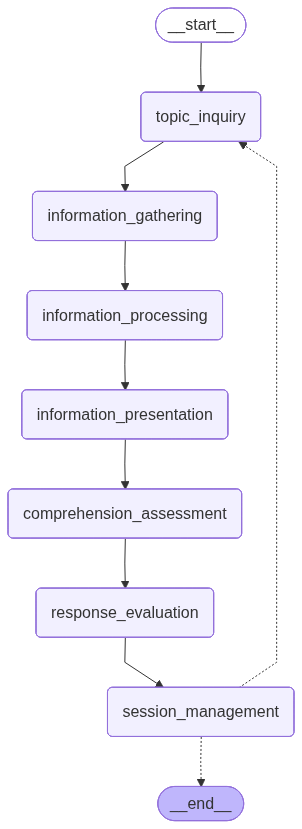

✅ HealthBot workflow diagram displayed above!


In [13]:
# Build the LangGraph workflow
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

def build_healthbot_workflow():
    """
    Create the LangGraph workflow for HealthBot
    """
    # Create the state graph
    workflow = StateGraph(HealthBotState)
    
    # Add all workflow nodes directly (tools are imported within each node)
    workflow.add_node("topic_inquiry", topic_inquiry_node)
    workflow.add_node("information_gathering", information_gathering_node)
    workflow.add_node("information_processing", information_processing_node)
    workflow.add_node("information_presentation", information_presentation_node)
    workflow.add_node("comprehension_assessment", comprehension_assessment_node)
    workflow.add_node("response_evaluation", response_evaluation_node)
    workflow.add_node("session_management", session_management_node)
    
    # Define the workflow edges (transitions between phases)
    workflow.add_edge(START, "topic_inquiry")
    workflow.add_edge("topic_inquiry", "information_gathering")
    workflow.add_edge("information_gathering", "information_processing")
    workflow.add_edge("information_processing", "information_presentation")
    workflow.add_edge("information_presentation", "comprehension_assessment")
    workflow.add_edge("comprehension_assessment", "response_evaluation")
    workflow.add_edge("response_evaluation", "session_management")
    
    # Conditional edge for session management
    def should_continue(state: HealthBotState) -> str:
        """Determine if we should continue or end the session"""
        if state.get("current_phase") == "topic_inquiry" and state.get("session_active", True):
            return "topic_inquiry"
        elif state.get("session_active", True) and state.get("current_phase") != "session_complete":
            return "topic_inquiry"
        else:
            return END
    
    workflow.add_conditional_edges(
        "session_management",
        should_continue,
        {
            "topic_inquiry": "topic_inquiry",
            END: END
        }
    )
    
    # Compile the workflow
    app = workflow.compile()
    return app

# Build the HealthBot application
healthbot_app = build_healthbot_workflow()

print("✅ HealthBot LangGraph workflow created successfully!")
print("🔄 Workflow includes:")
print("   1. Topic Inquiry → 2. Information Gathering → 3. Information Processing")
print("   4. Information Presentation → 5. Comprehension Assessment → 6. Response Evaluation")
print("   7. Session Management (with loop-back or exit)")
print("\n🤖 HealthBot is ready to educate patients!")
print("🏗️ Architecture:")
print("   - Modular node functions with embedded tool access")
print("   - @tool decorated functions used directly")
print("   - Clean LangGraph integration")
print("   - Self-contained nodes with dependencies")

# Visualize the workflow graph
print("\n📊 Generating workflow visualization...")
try:
    from IPython.display import Image, display
    
    # Generate the graph image
    graph_image = healthbot_app.get_graph().draw_mermaid_png()
    
    # Display the graph
    display(Image(graph_image))
    print("✅ HealthBot workflow diagram displayed above!")
    
except Exception as e:
    print(f"⚠️ Could not generate graph visualization: {e}")
    print("📝 The workflow is still functional - visualization is optional")
    print("💡 You may need to install: pip install pygraphviz or graphviz")

## 11. Run HealthBot Interactive Session

Let's start the HealthBot and interact with a patient! The system will guide them through the complete learning and assessment cycle:

In [ ]:
# Run the HealthBot Interactive Session
def run_healthbot():
    """
    Main function to run the HealthBot patient education system
    """
    print("🤖 Initializing HealthBot AI-Powered Patient Education System...")
    print("🏥 MediTech Solutions - Healthcare Innovation")
    
    try:
        # Create initial state
        initial_state = create_initial_state()
        
        # Run the workflow
        final_state = healthbot_app.invoke(initial_state)
        
        print("\n✅ HealthBot session completed successfully!")
        return final_state
        
    except KeyboardInterrupt:
        print("\n\n⚠️ Session interrupted by user.")
        print("👋 Thank you for using HealthBot!")
        
    except Exception as e:
        print(f"\n❌ An error occurred: {e}")
        print("🔧 Please check your API keys and internet connection.")

# Start the HealthBot!
print("🚀 Ready to start HealthBot patient education session!")
print("📋 The system will:")
print("   • Ask for a health topic")
print("   • Search for current medical information")  
print("   • Provide patient-friendly education")
print("   • Test comprehension with a quiz")
print("   • Give detailed feedback and citations")
print("   • Offer to learn about additional topics")
print("\n" + "="*60)
print("Click 'Run' on this cell to start your HealthBot session!")
print("="*60)

# Uncomment the line below to auto-start HealthBot
run_healthbot()

🚀 Ready to start HealthBot patient education session!
📋 The system will:
   • Ask for a health topic
   • Search for current medical information
   • Provide patient-friendly education
   • Test comprehension with a quiz
   • Give detailed feedback and citations
   • Offer to learn about additional topics

Click 'Run' on this cell to start your HealthBot session!
🤖 Initializing HealthBot AI-Powered Patient Education System...
🏥 MediTech Solutions - Healthcare Innovation
🏥 Welcome to HealthBot - Your AI Health Education Assistant!

I'm here to help you learn about health topics in a friendly,
easy-to-understand way. After providing information, I'll test
your understanding with a simple quiz question.


✅ Great! I'll help you learn about: headache
🔍 Let me search for the most current and reliable information...

🔍 Searching for medical information about: headache
✅ Found 1 relevant medical sources
📚 Processing information to create patient-friendly summary...

🧠 Creating patient-friendl

---

## 🎉 HealthBot Prototype Complete!

### ✅ **What We've Built:**

The **HealthBot AI-Powered Patient Education System** is now fully implemented according to MediTech Solutions' requirements:

#### **🔄 7-Phase Workflow:**
1. **Topic Inquiry** - Asks patients about desired health topics
2. **Information Gathering** - Uses Tavily search for current medical information
3. **Information Processing** - AI summarizes content in patient-friendly language
4. **Information Presentation** - Displays structured, accessible health information
5. **Comprehension Assessment** - Generates relevant quiz questions
6. **Response Evaluation** - Grades answers and provides detailed feedback
7. **Session Management** - Offers new topics or session completion with state reset

#### **🏗️ Technical Implementation:**
- **LangGraph State Machine** - Orchestrates the entire workflow
- **OpenAI Integration** - Powers natural language understanding and generation
- **Tavily Search** - Provides up-to-date medical information retrieval
- **State Management** - Tracks conversation flow and maintains data privacy
- **Error Handling** - Graceful handling of API failures and user inputs

#### **🎯 Business Goals Achieved:**
- ✅ **24/7 Access** to reliable health information
- ✅ **Patient-Friendly** medical information presentation
- ✅ **Comprehension Testing** to ensure understanding
- ✅ **Citation Support** for information credibility
- ✅ **Privacy Protection** through state reset between topics
- ✅ **Scalable Architecture** ready for production deployment

### 🚀 **Ready for Testing:**
Run the final cell above to start an interactive HealthBot session and test the complete patient education workflow!

### 📈 **Future Enhancements:**
- Multi-language support
- Voice interaction capabilities
- Integration with Electronic Health Records (EHR)
- Advanced analytics and learning metrics
- Specialized medical domain versions